In [2]:
import os
import caesar
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import modules as anal
import modules.anal_func as anal_func

from astropy.cosmology import LambdaCDM
import astropy.units as u
from astropy.io import fits
from scipy import interpolate

from modules.anal_func.build_history import BuildHistory
from modules.anal_func.read_progenitors import read_progen

from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np


cosmo = LambdaCDM(H0 = 68, Om0= 0.3, Ode0= 0.7, Ob0=0.048)
plt.rcParams.update({'font.size': 28})

In [9]:
# initialize the Simba class, which import the needed paths
sb = anal.Simba('PC39BP4', size=100)
# initialize the SavePaths class to create destinations
sv = anal.SavePaths() 
pltsv  = sv.get_filetype_path('plot')
scatter = sv.create_subdir(pltsv, 'scatter')

In [ ]:
cs = sb.get_caesar(151)
totids = np.asarray([i.GroupID for i in cs.galaxies])
sfh = BuildHistory(sb, '/home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5', progfilename='progenitors_recursive.fits') #'progenitors_recursive.fits') #'progenitors_most_mass_nocaesar.fits')

yt : [INFO     ] 2025-06-20 14:59:56,559 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_151.hdf5
yt : [INFO     ] 2025-06-20 14:59:56,568 Found 464043 halos
yt : [INFO     ] 2025-06-20 14:59:56,571 Found 55609 galaxies


In [11]:
hist = sfh.get_history_indx(totids[:], start_snap=150, end_snap=62)

In [ ]:
positions = sfh.get_property_history(['pos_0', 'pos_1' , 'pos_2', 'GroupID', 'sfr', 'stellar_masses'])

Number of snapshots: 89
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_150.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_149.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_148.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_147.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_146.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_145.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_144.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_143.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_142.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_141.fits


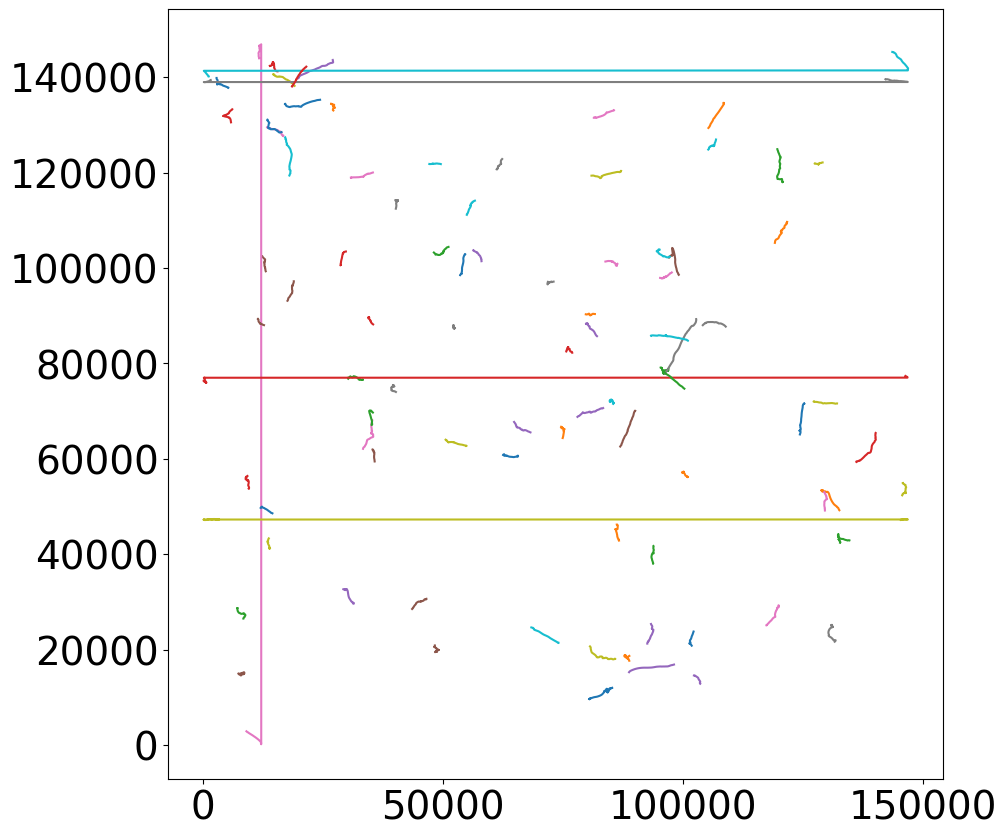

In [ ]:
plt.figure(figsize=(10, 10))
for i in range(len(positions['pos_0'][:])):
    plt.plot(positions['pos_0'][:,i], positions['pos_1'][:,i])

In [ ]:
# define our redshift range
z = sb.get_z_from_snap(np.arange(44, 150, 1))
tcosmo = cosmo.age(z).value

indx = -16
print('z = ', z[indx])
print(np.log10(0.2/cosmo.age(z[indx]).to(u.yr).value), 'Gyr')

In [ ]:
# Specific SFR selection
ssfr = np.log10(positions['sfr'][indx, :] / positions['stellar_masses'][indx, :])
ssfr_cut = ssfr < np.log10(0.2/cosmo.age(z[indx]).to(u.yr).value)
galaxy_selection = np.where(ssfr_cut)[0]
print(f"Number of galaxies selected: {len(galaxy_selection)} over {len(positions['stellar_masses'][indx, :])} total galaxies.")


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

group_ids = positions['GroupID']  # shape (n_snap, n_gal) or maybe (1, n_gal) if static
pos_x = positions['pos_0']  # shape (n_snap, n_gal)
pos_y = positions['pos_1']

target_ids = positions['GroupID'][-1, galaxy_selection][:30]  # selected at last snapshot

for tgt_id in target_ids:
    # Get the IDs of potential mergers for this target galaxy
    merger_ids = merger_dict.get(tgt_id, set())

    # Combine the target galaxy + its mergers
    all_ids = [tgt_id] + list(merger_ids)

    # Find their indices in the global array (assuming GroupID doesn't change over snapshots)
    indices = [np.where(group_ids[-1] == gid)[0][0] for gid in all_ids]

    # Plot their positions over time
    plt.figure(figsize=(12, 12))
    for idx in indices:
        plt.plot(pos_x[:, idx], pos_y[:, idx], marker='o', markersize=2, label=f'ID {group_ids[-1, idx]}')
        plt.scatter(pos_x[0, idx], pos_y[0, idx], s=100, label=f'Start Position ID {group_ids[-1, idx]}', edgecolor='black')
    
    plt.xlabel('X [cMpc]')
    plt.ylabel('Y [cMpc]')
    plt.title(f'Galaxy {tgt_id} and Merger Companions (Trajectories)')
    plt.tight_layout()
    plt.show()


In [ ]:
def find_disrupted_galaxies(positions, merger_dict, group_ids):
    pos_x = positions['pos_0']  # shape (n_snap, n_gal)
    n_snap, n_gal = pos_x.shape

    disrupted_info = {}  # key: main galaxy ID, value: list of dicts for disrupted galaxies

    for main_id, candidate_ids in merger_dict.items():
        disrupted_info[main_id] = []
        print(f"Processing main galaxy {main_id} with {len(candidate_ids)} candidates...")

        for cid in candidate_ids:
            # Get index of this candidate galaxy
            try:
                idx = np.where(group_ids == cid)[0][0]
            except IndexError:
                continue  # GroupID not found in last snapshot

            # Track whether the galaxy was alive and when it disappeared
            pos_time_series = pos_x[:, idx]
            not_nan_mask = ~np.isnan(pos_time_series)

            if np.any(not_nan_mask):
                first_nan_after_real = np.where((~not_nan_mask[:-1]) & not_nan_mask[1:])[0]
                # Better logic: find the **first index where it becomes NaN after being real**
                last_real_idx = np.where(not_nan_mask)[0][-1]
                if last_real_idx < n_snap - 1:
                    # Galaxy is gone after last_real_idx
                    snapshot_disrupted = last_real_idx + 1  # first NaN
                    disrupted_info[main_id].append({
                        'id': cid,
                        'disrupted_at': snapshot_disrupted,
                        'index': idx
                    })

    return disrupted_info


In [ ]:
disrupted_info = find_disrupted_galaxies(positions, merger_dict, positions['GroupID'])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

group_ids = positions['GroupID']  # shape (n_snap, n_gal) or maybe (1, n_gal) if static
pos_x = positions['pos_0']  # shape (n_snap, n_gal)
pos_y = positions['pos_1']

target_ids = positions['GroupID'][-1, galaxy_selection][:3]  # selected at last snapshot

for tgt_id in target_ids:
    # Get the IDs of potential mergers for this target galaxy
    merger_ids = merger_dict.get(tgt_id, set())

    # Combine the target galaxy + its mergers
    all_ids = [tgt_id] + list(merger_ids)

    # Find their indices in the global array (assuming GroupID doesn't change over snapshots)
    indices = [np.where(group_ids[-1] == gid)[0][0] for gid in all_ids]

    for idx in indices:
        print(pos_x[-1, idx])

    



In [ ]:
import numpy as np
import h5py
from astropy.io import fits
from astropy.table import Table

def build_progenitor_groupid_table(simba_obj, snaplist, output_fits, base_snap=151):
    """
    Build a progenitor table: each row corresponds to a galaxy in base_snap,
    and each column gives the GroupID of its main progenitor at that snapshot.
    """
    snaplist = sorted(snaplist, reverse=True)
    print(f'The base snap is {snaplist[0]}')  # descending order

    print(f"Tracking progenitors from snapshot {base_snap} back to {snaplist[-1]}")
    prog_table = None

    for si, snap in enumerate(snaplist):
        fpath = simba_obj.get_caesar_file(snap)

        with h5py.File(fpath, 'r') as f:
            if si == 0:
                print(f"Processing snapshot {fpath}...")
                print(f"Reading progenitor data from the first snapshot {snap}...")
                progenid = np.array(f['tree_data']['progen_galaxy_star'][:, 0])
                current_indices = np.array(f['galaxy_data']['GroupID'])
                prevprog = current_indices
                prog_table = np.full((len(current_indices), len(snaplist)), -1, dtype=int)
                print('GroupIDs: ', current_indices)
                print('Initial progenitor indices:', progenid)
                print('=========================================================================')

            else:
                print(f"Processing snapshot {fpath}...")
                progenid = np.array(f['tree_data']['progen_galaxy_star'])[prevprog][:, 0]
                current_indices = np.array(f['galaxy_data']['GroupID'])
                print('Current GroupIDs: ', current_indices)
                print('Progenitor indices from previous step:', prevprog)
                valid = np.where(progenid >= 0)[0]
                progenid = progenid[valid]

            # prevprog are indices into progenitor array
            valid = np.where(prevprog >= 0)[0]
            prog_table[valid, si] = current_indices[prevprog[valid]]

            print(prog_table[valid, si])
            print('=========================================================================')

            prevprog = progenid

    # Build Astropy Table
    colnames = [str(snap) for snap in snaplist]
    table = Table(prog_table, names=colnames)

    # Write to FITS file
    table.write(output_fits, format='fits', overwrite=True)
    print(f"Saved progenitor GroupID table to {output_fits}")

    # Print first 10 rows nicely
    print("\nFirst 10 rows of the progenitor table:\n")
    print(table[:10])


In [ ]:
from modules.io_paths import SavePaths
import h5py
cs = sb.get_caesar(151)
totids = np.asarray([i.GroupID for i in cs.galaxies])
sb = anal.Simba('PC39BP4', size=100)
snaplist = list(range(151, 61, -1))  # or whatever range you need
paths = SavePaths()
outdir = paths.create_subdir(paths.get_filetype_path('fits'), 'progenitors_files')
output_fits = os.path.join(outdir, 'progenitors_recursive.fits')

build_progenitor_groupid_table(sb, snaplist, output_fits)


yt : [INFO     ] 2025-06-19 12:47:33,089 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_151.hdf5
yt : [INFO     ] 2025-06-19 12:47:33,098 Found 464043 halos
yt : [INFO     ] 2025-06-19 12:47:33,101 Found 55609 galaxies


The base snap is 151
Tracking progenitors from snapshot 151 back to 62
Processing snapshot /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_151.hdf5...
Reading progenitor data from the first snapshot 151...
GroupIDs:  [    0     1     2 ... 55606 55607 55608]
Initial progenitor indices: [ 0  1  2 ... -1 -1 -1]
[    0     1     2 ... 55606 55607 55608]
Processing snapshot /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_150.hdf5...
Current GroupIDs:  [    0     1     2 ... 55333 55334 55335]
Progenitor indices from previous step: [ 0  1  2 ... -1 -1 -1]
[    0     1     2 ... 55257 54582 50133]
Processing snapshot /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_149.hdf5...
Current GroupIDs:  [    0     1     2 ... 55058 55059 55060]
Progenitor indices from previous step: [    0     1     2 ... 52407 50861 53237]
[    0     1     2 ... 52407 50861 53237]
Processing snapshot /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_148.hdf5...
Current GroupIDs:  [    0     1     2 ... 54403 54404 544

In [ ]:
import caesar
import numpy as np
from astropy.io import fits
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor
import time
import gc
import os
from scipy.spatial import cKDTree



# Parameters — EDIT THESE TO YOUR PATHS AND VALUES
caesar_dir = Path("/media/lorenzong/Data1/SIMBA_catalogs/")
fits_file = "/home/lorenzong/analize_simba_cgm/output/fits/progenitors_files/progenitors_recursive.fits"
search_radius_kpc = 100
velocity_threshold = 300
max_workers = 2  # Increase if you want more parallelism and have enough RAM

# Load progenitor index table
with fits.open(fits_file) as hdul:
    progenitor_data = hdul[1].data
    snap_names = hdul[1].columns.names[85:96][::-1]
  # from high z to low z
progenitor_table = np.vstack([progenitor_data[col] for col in snap_names]).T
n_galaxies, n_snaps = progenitor_table.shape
n_snaps = len(snap_names)

def get_catalog(snapnum):
    fname = caesar_dir / f"m100n1024_{snapnum:03d}.hdf5"
    return caesar.load(fname)

def process_snapshot_vectorized(snap_idx):
    import warnings
    warnings.filterwarnings("ignore")

    snap1 = int(snap_names[snap_idx])
    snap2 = int(snap_names[snap_idx + 1])

    try:
        cat1 = get_catalog(snap1)
        cat2 = get_catalog(snap2)
    except Exception as e:
        print(f"[PID {os.getpid()}] ERROR loading catalogs {snap1}-{snap2}: {e}", flush=True)
        return (snap1, None, None, None)

    # Prepare numpy arrays for snapshot 1
    pos1 = np.array([g.pos.to('kpccm').value for g in cat1.galaxies])
    vel1 = np.array([g.vel for g in cat1.galaxies])
    mstar1 = np.array([g.masses['stellar'] for g in cat1.galaxies])
    groupid1 = np.array([g.GroupID for g in cat1.galaxies])

    # Prepare numpy arrays for snapshot 2
    pos2 = np.array([g.pos.to('kpccm').value for g in cat2.galaxies])
    vel2 = np.array([g.vel for g in cat2.galaxies])
    mstar2 = np.array([g.masses['stellar'] for g in cat2.galaxies])
    groupid2 = np.array([g.GroupID for g in cat2.galaxies])

    tree1 = cKDTree(pos1)
    tree2 = cKDTree(pos2)

    nparts_array = np.full(n_galaxies, -1)
    nsats_array = np.full(n_galaxies, -1)
    mergers_array = np.full(n_galaxies, -1)
    merger_mass_array = np.full(n_galaxies, -1.0) 

    for gal_idx in range(n_galaxies):
        idx1 = progenitor_table[gal_idx, snap_idx]
        idx2 = progenitor_table[gal_idx, snap_idx + 1]
        if idx1 < 0 or idx2 < 0 or idx1 >= len(cat1.galaxies) or idx2 >= len(cat2.galaxies):
            continue

        try:
            m1 = mstar1[idx1]
            p1 = pos1[idx1]
            v1 = vel1[idx1]
            g1_group = groupid1[idx1]

            m2 = mstar2[idx2]
            p2 = pos2[idx2]
            v2 = vel2[idx2]
            g2_group = groupid2[idx2]

            gal1 = cat1.galaxies[idx1]
            nparts_array[gal_idx] = len(gal1.slist) + len(gal1.glist)

            # neighbors in snap1
            idxs_neigh1 = tree1.query_ball_point(p1, search_radius_kpc)
            filtered_neigh1 = []
            for ni in idxs_neigh1:
                if ni == idx1:
                    continue
                if groupid1[ni] == g1_group:
                    continue
                if mstar1[ni] <= 0.001 * m1:
                    continue
                if np.linalg.norm(vel1[ni] - v1) >= velocity_threshold:
                    continue
                filtered_neigh1.append(ni)
            nsats_array[gal_idx] = len(filtered_neigh1)

            # neighbors in snap2
            idxs_neigh2 = tree2.query_ball_point(p2, search_radius_kpc)
            filtered_neigh2 = []
            for ni in idxs_neigh2:
                if ni == idx2:
                    continue
                if groupid2[ni] == g2_group:
                    continue
                if mstar2[ni] <= 0.001 * m2:
                    continue
                if np.linalg.norm(vel2[ni] - v2) >= velocity_threshold:
                    continue
                filtered_neigh2.append(ni)

            if len(filtered_neigh1) > len(filtered_neigh2) and len(filtered_neigh1) > 0:
                most_massive_idx = max(filtered_neigh1, key=lambda i: mstar1[i])
                most_massive_mass = mstar1[most_massive_idx]
                mergers_array[gal_idx] = groupid1[most_massive_idx]
                merger_mass_array[gal_idx] = most_massive_mass/gal1.masses['stellar']  # mass ratio

        except Exception as e:
            print(f"[PID {os.getpid()}] ERROR in galaxy {gal_idx} of snap {snap1}: {e}", flush=True)
            continue

    del cat1, cat2, tree1, tree2
    gc.collect()

    print(f"[PID {os.getpid()}] Finished snapshot {snap1}", flush=True)
    return (snap1, nparts_array, nsats_array, mergers_array, merger_mass_array)



if __name__ == "__main__":

    print(f"[Main] Starting snapshot processing with {max_workers} workers", flush=True)
    t0 = time.time()

    # Adjust range(10) as needed for your number of snapshots
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        results = list(executor.map(process_snapshot_vectorized, range(n_snaps - 1)))

    # Updated results collection
    results = [r for r in results if r[3] is not None]  # still checking mergers_array

    snap_nums = []
    merger_id_data = []
    merger_mass_data = []

    for snap1, _, _, mergers_array, merger_mass_array in results:
        snap_nums.append(snap1)
        merger_id_data.append(mergers_array)
        merger_mass_data.append(merger_mass_array)

    merger_id_data = np.array(merger_id_data).T  # (n_gal, n_snap)
    merger_mass_data = np.array(merger_mass_data).T


    # IDs file
    cols_id = [fits.Column(name='GalaxyID', array=np.arange(merger_id_data.shape[0]), format='K')]
    for i, snap in enumerate(snap_nums):
        cols_id.append(fits.Column(name=f'{snap}', array=merger_id_data[:, i], format='K'))

    hdu_id = fits.PrimaryHDU()
    tbhdu_id = fits.BinTableHDU.from_columns(cols_id)
    hdul_id = fits.HDUList([hdu_id, tbhdu_id])
    hdul_id.writeto("mergers_ids.fits", overwrite=True)

    # Masses file
    cols_mass = [fits.Column(name='GalaxyID', array=np.arange(merger_mass_data.shape[0]), format='K')]
    for i, snap in enumerate(snap_nums):
        cols_mass.append(fits.Column(name=f'{snap}', array=merger_mass_data[:, i], format='D'))  # float64

    hdu_mass = fits.PrimaryHDU()
    tbhdu_mass = fits.BinTableHDU.from_columns(cols_mass)
    hdul_mass = fits.HDUList([hdu_mass, tbhdu_mass])
    hdul_mass.writeto("mergers_masses_patch.fits", overwrite=True)



[Main] Starting snapshot processing with 2 workers


yt : [INFO     ] 2025-06-20 14:59:50,082 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_063.hdf5
yt : [INFO     ] 2025-06-20 14:59:50,082 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_062.hdf5
yt : [INFO     ] 2025-06-20 14:59:50,111 Found 497446 halos
yt : [INFO     ] 2025-06-20 14:59:50,111 Found 502944 halos
yt : [INFO     ] 2025-06-20 14:59:50,120 Found 24546 galaxies
yt : [INFO     ] 2025-06-20 14:59:50,120 Found 24860 galaxies
yt : [INFO     ] 2025-06-20 14:59:50,126 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_064.hdf5
yt : [INFO     ] 2025-06-20 14:59:50,125 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_063.hdf5
yt : [INFO     ] 2025-06-20 14:59:50,139 Found 502944 halos
yt : [INFO     ] 2025-06-20 14:59:50,139 Found 507778 halos
yt : [INFO     ] 2025-06-20 14:59:50,147 Found 24860 galaxies
yt : [INFO     ] 2025-06-20 14:59:50,147 Found 25203 galaxies


[PID 26556] Finished snapshot 62


yt : [INFO     ] 2025-06-20 14:59:51,943 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_064.hdf5
yt : [INFO     ] 2025-06-20 14:59:51,955 Found 507778 halos


[PID 26557] Finished snapshot 63


yt : [INFO     ] 2025-06-20 14:59:51,964 Found 25203 galaxies
yt : [INFO     ] 2025-06-20 14:59:51,968 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_065.hdf5
yt : [INFO     ] 2025-06-20 14:59:51,969 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_065.hdf5
yt : [INFO     ] 2025-06-20 14:59:51,982 Found 512724 halos
yt : [INFO     ] 2025-06-20 14:59:51,982 Found 512724 halos
yt : [INFO     ] 2025-06-20 14:59:51,990 Found 25513 galaxies
yt : [INFO     ] 2025-06-20 14:59:51,990 Found 25513 galaxies
yt : [INFO     ] 2025-06-20 14:59:51,995 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_066.hdf5
yt : [INFO     ] 2025-06-20 14:59:52,007 Found 516483 halos
yt : [INFO     ] 2025-06-20 14:59:52,015 Found 25918 galaxies


[PID 26556] Finished snapshot 64
[PID 26557] Finished snapshot 65


In [3]:
# initialize the Simba class, which import the needed paths
sb = anal.Simba('PC39BP4', size=100)
# initialize the SavePaths class to create destinations
sv = anal.SavePaths() 
pltsv  = sv.get_filetype_path('plot')
scatter = sv.create_subdir(pltsv, 'scatter')
cs = sb.get_caesar(150)
totids = np.asarray([i.GroupID for i in cs.galaxies])
sfh = BuildHistory(sb, '/home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5', progfilename='progenitors_recursive.fits') #'progenitors_recursive.fits') #'progenitors_most_mass_nocaesar.fits')

hist = sfh.get_history_indx(totids[:], start_snap=150, end_snap=62)

yt : [INFO     ] 2025-06-20 15:05:21,495 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_150.hdf5
yt : [INFO     ] 2025-06-20 15:05:21,513 Found 465211 halos
yt : [INFO     ] 2025-06-20 15:05:21,517 Found 55336 galaxies


In [4]:
dustegas = sfh.get_property_history(['dust_masses', 'H2_masses' , 'GroupID', 'sfr', 'stellar_masses'])

Number of snapshots: 89
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_150.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_149.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_148.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_147.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_146.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_145.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_144.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_143.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_142.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_141.fits
Opening /home/lorenzong/analize_simba_cgm/outp

In [28]:
# define our redshift range
z = sb.get_z_from_snap(np.arange(62, 151, 1))
print(z.shape)
print(dustegas['GroupID'].shape)
tcosmo = cosmo.age(z).to(u.yr).value

indx = -18
print('z = ', z[indx])
print(np.log10(0.2/cosmo.age(z[indx]).to(u.yr).value), 'Gyr')

(89,)
(89, 55336)
z =  0.32504385895173127
-10.703743181289862 Gyr


In [38]:
# Load all data, including possible NaNs
data = np.genfromtxt('/home/lorenzong/analize_simba_cgm/analize_simba_cgm_code/test_qt_out_034_rev.txt')

# Remove rows with any NaN
data_clean = data[~np.isnan(data).any(axis=1)]

# Unpack cleaned columns
filtid, esf, qm, qt, tsq = data_clean.T
filtid = filtid.astype(int)

In [30]:
import pandas as pd
from astropy.io import fits

# Load the FITS file
mergfile = '/home/lorenzong/analize_simba_cgm/analize_simba_cgm_code/mergers_full_tracks.fits'
with fits.open(mergfile) as hdul:
    data = hdul[1].data
    df = pd.DataFrame(np.array(data).byteswap().newbyteorder())  # ensure endianness is right

# Identify existing snapshot columns (they are integers as strings)
existing_snapshots = sorted([int(col) for col in df.columns if col.isdigit()])
full_range = list(range(62, 150))  # snapshots from 62 to 149

# Find missing columns
missing = sorted(set(full_range) - set(existing_snapshots))

# Add missing columns filled with -1
for snap in missing:
    df[str(snap)] = -1

# Reorder columns: keep 'GalaxyID' first, then numerical columns sorted
cols = ['GalaxyID'] + sorted([col for col in df.columns if col != 'GalaxyID'], key=lambda x: int(x))
df = df[cols]

# Done!
print(f"Added missing snapshot columns: {missing}")


Added missing snapshot columns: [91, 121]


In [71]:
selected_rows = df.iloc[filtid.astype(int)]

merger_columns = [col for col in selected_rows.columns if col != 'GalaxyID']

# This extracts the data as a 2D numpy array: shape (n_rows, n_columns)
merger_data = selected_rows[merger_columns].to_numpy()


n_galaxies = merger_data.shape[0]
n_snapshots = merger_data.shape[1]

num_gt_025_arr = np.zeros(n_galaxies, dtype=int)
num_lt_025_arr = np.zeros(n_galaxies, dtype=int)

for g in range(n_galaxies):
    # Boolean mask for snapshots where tcosmo > esf for this galaxy
    quenched = tcosmo > esf[g]
    # Select snapshot values for this galaxy where quenched is True
    vals = merger_data[g, quenched]
    num_gt_025_arr[g] = np.sum(vals > 0.25)
    num_lt_025_arr[g] = np.sum((vals > 1/500) & (vals <= 0.25))






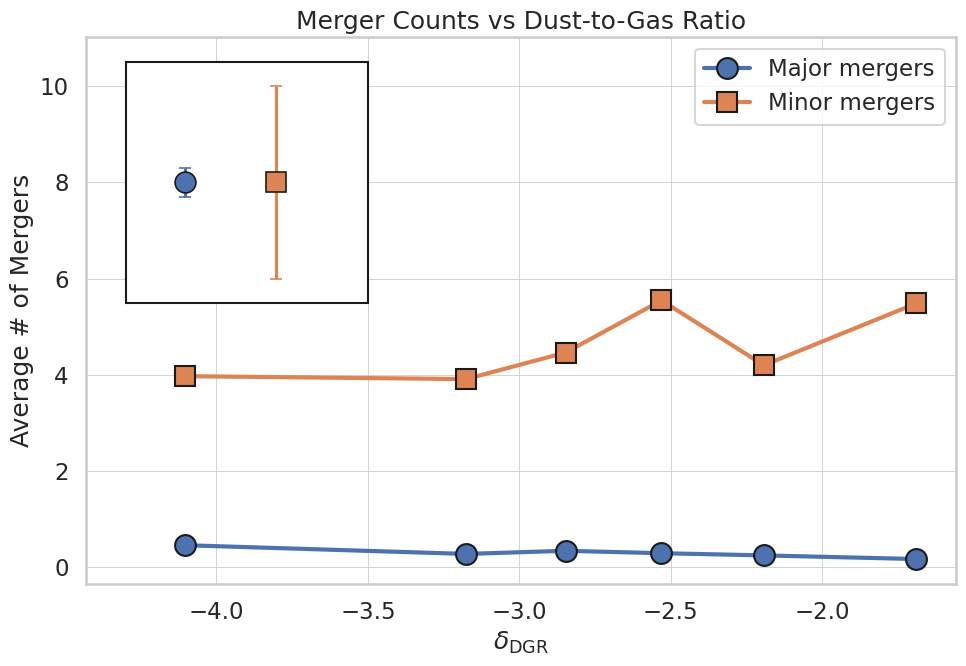

In [143]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.stats import binned_statistic
import seaborn as sns

# Apply seaborn styling
sns.set(style='whitegrid', context='talk', palette='deep')

# Remove NaNs or infinities
nonan = np.isfinite(dgr) & np.isfinite(num_gt_025_arr) & np.isfinite(num_lt_025_arr)
dgr_clean = dgr[nonan]
gt_clean = num_gt_025_arr[nonan]
lt_clean = num_lt_025_arr[nonan]

# Define number of bins
nbins = 6

# Compute quantile-based (equipopulated) bin edges
bins = np.quantile(dgr_clean, np.linspace(0, 1, nbins + 1))
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Compute binned statistics
mean_gt, _, _ = binned_statistic(dgr_clean, gt_clean, statistic='mean', bins=bins)
std_gt, _, _ = binned_statistic(dgr_clean, gt_clean, statistic='std', bins=bins)

mean_lt, _, _ = binned_statistic(dgr_clean, lt_clean, statistic='mean', bins=bins)
std_lt, _, _ = binned_statistic(dgr_clean, lt_clean, statistic='std', bins=bins)

plt.figure(figsize=(10, 7))

# Plot mean curves with black edges on markers
plt.plot(bin_centers, mean_gt, '-o', label='Major mergers', lw=3, markersize=15,
         markeredgecolor='k', markeredgewidth=1.5)
plt.plot(bin_centers, mean_lt, '-s', label='Minor mergers', lw=3, markersize=15,
         markeredgecolor='k', markeredgewidth=1.5)

plt.xlabel(r'$\delta_{\mathrm{DGR}}$')
plt.ylabel('Average # of Mergers')
plt.title('Merger Counts vs Dust-to-Gas Ratio')

# Calculate average std dev for errorbars (using median / 2)
avg_err_gt = np.nanmedian(std_gt) / 2
avg_err_lt = np.nanmedian(std_lt) / 2

ax = plt.gca()

# Get y-axis limits to place the example errorbars nicely
ylim = plt.ylim()
x_pos = bin_centers[0]
y_pos_gt = 8
y_pos_lt = 8

# White box covering grid behind the errorbars/text
box_x = -4.3  # left edge in data coords (adjust as needed)
box_width = 0.8  # cover full width + a bit extra
box_y = 5.5  # start just at top of axes
box_height = 5  # cover top 30% above axes limits

rect = Rectangle((box_x, box_y), box_width, box_height,
                 facecolor='white', edgecolor='k', zorder=1, alpha=1.0)
ax.add_patch(rect)

# Plot example errorbars for avg errors with smaller markers and caps on top of box
plt.errorbar(x_pos, y_pos_gt, yerr=avg_err_gt, fmt='o', color='C0', capsize=4, markersize=15,
             markeredgecolor='k', markeredgewidth=1.2, label='_nolegend_')

plt.errorbar(x_pos + 0.3, y_pos_lt, yerr=avg_err_lt, fmt='s', color='C1', capsize=4, markersize=15,
             markeredgecolor='k', markeredgewidth=1.2, label='_nolegend_')

# Thinner grid lines
plt.grid(linewidth=0.6)

plt.legend(loc='upper right')
plt.tight_layout()
#plt.show()
plt.savefig('/home/lorenzong/analize_simba_cgm/output/plot/mergers/merger_fraction_dgr.png')
